# Multiple Schemas
- Private Schemas
- Input & Output schemas (filters)

### Boilerplate code - llm initiation

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv

load_dotenv("./env")

google_api_key = os.getenv("GOOGLE_API_KEY")
openai_api_key = os.getenv("OPENAI_API_KEY")

google_llm = ChatGoogleGenerativeAI(
    temperature=0, 
    model="gemini-2.5-flash", 
    api_key=google_api_key,
    max_tokens=200
)

openai_llm = ChatOpenAI(
    temperature=0, 
    model="gpt-4", 
    api_key=openai_api_key
)

# openai_llm.invoke("Hello")

### Having Two schemas

{'main_num': 3}


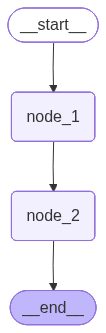

In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from IPython.display import display, Image

class MainState(TypedDict):
    main_num: int

class SubState(TypedDict):
    sub_num: int


def node_1(state: MainState) -> SubState:
    return {"sub_num": state['main_num'] + 1}

def node_2(state: SubState) -> MainState:
    return {"main_num": state["sub_num"] + 1}


builder = StateGraph(MainState)

builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)

builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

graph = builder.compile()


res = graph.invoke({"main_num": 1})

print(res)

display(Image(graph.get_graph().draw_mermaid_png()))

### Input/Output schemas

{'country': 'India', 'profession': 'Software'}


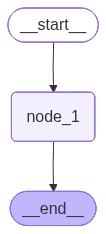

In [16]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from IPython.display import display, Image


class MainState(TypedDict):
    name: str
    country: str
    profession: str


class InputState(TypedDict):
    name: str

class OutputState(TypedDict):
    country: str
    profession: str


def node_1(state):
    return {"country": "India", "profession": "Software", "test":"test"}


builder = StateGraph(MainState, input_schema=InputState, output_schema=OutputState)

builder.add_node("node_1", node_1)

builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

graph = builder.compile()


res = graph.invoke({"name": "Praveen"})

print(res)

display(Image(graph.get_graph().draw_mermaid_png()))